# Exercises XP: Guided Student Notebook

This guided notebook follows the **content on the platform**. Some cells are **prefilled** and must be **executed only**. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

**Learning points** appear when a concept is important for intuition or to help you learn new tricks/concepts related to other AI topics.


## Objectives

**What you will learn**  
- The fundamentals of deep learning and neural networks.
- How to build and train simple neural networks using TensorFlow or Keras.
- The concepts of forward and backward propagation.
- How to visualize and interpret model predictions.

**What you will create**  
- A simple perceptron-based decision system.
- A neural network for classifying handwritten digits from the MNIST dataset.
- A forward propagation calculation for predicting house prices.
- A Python implementation of forward and backward propagation.
- Visualizations of predictions made by a neural network on the MNIST dataset.


## 🌟 Exercise 1: Small Quiz

**As stated in the instructions**  
- What is the key difference between traditional machine learning and deep learning?  
- How do artificial neural networks mimic the human brain?  
- Why does deep learning perform better on large datasets compared to traditional machine learning?  
- What are some challenges of deep learning, and how can they be addressed?  
- What is feature engineering, and why is it not needed in deep learning?  
- What role do hidden layers play in a deep learning model?  
- In an artificial neural network, what is the function of an activation function?

**Guidance**  
Answer in full sentences. Use concise definitions first, then add one concrete example for any two questions to demonstrate understanding.

**To-Do:** Write your answers below.


### Answers

**1. Key difference between traditional ML and deep learning.**
Traditional machine learning relies on hand-crafted features that a human engineer designs before the model can learn, and it typically uses simpler algorithms (e.g. logistic regression, SVM, random forests). Deep learning uses multi-layered neural networks that learn the relevant features automatically from raw data, so representation and prediction are learned jointly.

**2. How artificial neural networks mimic the human brain.**
ANNs are loosely inspired by biological neurons: each artificial neuron receives weighted inputs (analogous to synaptic strengths), sums them with a bias, and passes the result through an activation function that decides whether and how strongly the neuron "fires." Many such neurons are connected in layers, so signals propagate through the network much as they do across networks of biological neurons.

**3. Why deep learning performs better on large datasets.**
Deep networks have a very large number of parameters and high capacity, so they need a lot of data to learn good representations without overfitting. When given large datasets, they can discover rich hierarchical patterns and keep improving, whereas traditional models tend to plateau in performance once their fixed, hand-made features are saturated. *Example:* on ImageNet (millions of images) a deep convolutional network dramatically outperforms a classical feature-based classifier.

**4. Challenges of deep learning and how to address them.**
Key challenges include the need for large labeled datasets, high computational cost, long training times, overfitting, and poor interpretability. These can be addressed with data augmentation and transfer learning (less data needed), GPUs/TPUs and efficient architectures (compute), regularization such as dropout, weight decay, and early stopping (overfitting), and explainability tools like saliency maps or SHAP (interpretability).

**5. What feature engineering is, and why deep learning needs it less.**
Feature engineering is the manual process of transforming raw data into informative input variables (e.g. computing ratios, extracting edges from an image, building TF‑IDF vectors from text). Deep learning needs little of it because the hidden layers learn useful features directly from raw data during training. *Example:* instead of manually designing edge and shape detectors for digit recognition, a neural network learns those detectors on its own from the pixel values.

**6. Role of hidden layers.**
Hidden layers transform the input into progressively more abstract representations. Early layers capture simple patterns (edges, basic combinations) and deeper layers combine them into higher-level concepts, enabling the network to model complex, non-linear relationships between inputs and outputs.

**7. Function of an activation function.**
An activation function introduces non-linearity, allowing the network to approximate complex functions rather than just linear mappings. It also shapes each neuron's output (e.g. ReLU keeps positive values and zeros out negatives, softmax turns logits into a probability distribution), which controls how information flows and how the model is trained via gradients.


## 🌟 Exercise 2: Building a Simple Perceptron Decision System

**As stated in the instructions**  
You will create a perceptron-based decision system to decide whether you should go outside based on two inputs:
- Temperature in °F
- Rainy where Yes is 1 and No is 0

Given parameters: Temperature weight 0.6, Rain weight 0.4, Bias 2. Compute the weighted sum
\[ \text{Weighted Sum} = 0.6\cdot \text{Temperature} + 0.4\cdot \text{Rain} + \text{Bias} \]
Apply a step activation:
- If Weighted Sum > 20, output 1
- If Weighted Sum \le 20, output 0

Evaluate:  
Case 1: Temperature 70°F, Rain 0  
Case 2: Temperature 50°F, Rain 1

**Guidance**  
Implement the weighted sum function yourself. Use a reusable step activation. Then compute the two cases and print the decision for each.

**Learning point**  
A perceptron implements a linear decision boundary. The bias shifts the threshold. Use step activation for simple binary rules. Prefer differentiable activations when training with gradient descent.

![image.png](https://github.com/user-attachments/assets/3c4f3261-164d-4039-8e1c-aff2db7162dd)


In [1]:
# PREFILLED: just execute
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s > threshold else 0


In [2]:
# To-Do: implement weighted_sum then use it to compute the two cases
def weighted_sum(temperature_f: float, rain01: int) -> float:
    """Compute s = 0.6*Temperature + 0.4*Rain + Bias."""
    return W_TEMP * temperature_f + W_RAIN * rain01 + BIAS

# To-Do: compute decisions for the two cases and print them
case1 = (70, 0)  # Temperature=70, Rain=0
case2 = (50, 1)  # Temperature=50, Rain=1

s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)
y1 = step_activation(s1)
y2 = step_activation(s2)

print({"case1": {"sum": s1, "decision": y1}, "case2": {"sum": s2, "decision": y2}})


{'case1': {'sum': 44.0, 'decision': 1}, 'case2': {'sum': 32.4, 'decision': 1}}


**To-Do:** Interpret your results.

**Answer.** In both cases the perceptron suggests going outside (decision = 1).

- **Case 1 (70°F, no rain):** weighted sum = 0.6·70 + 0.4·0 + 2 = **44**. Since 44 > 20, the step activation outputs **1** → go outside.
- **Case 2 (50°F, raining):** weighted sum = 0.6·50 + 0.4·1 + 2 = **32.4**. Since 32.4 > 20, the step activation outputs **1** → go outside.

The decision is governed by the threshold rule: the neuron "fires" (outputs 1) only when the weighted sum exceeds 20. Here the temperature dominates the sum because it has a large weight (0.6) and large magnitude, so even a cooler, rainy day (Case 2) still clears the threshold comfortably. The **bias (+2)** simply shifts the weighted sum upward, making it slightly easier to cross the threshold; a larger negative bias (or a higher threshold) would be required to make the model decide "stay inside" on a mild rainy day. In short, with these particular weights and threshold the rule is quite permissive, which is why both cases return "go outside."


## 🌟 Exercise 3: Building a Simple Neural Network with TensorFlow or Keras

**As stated in the instructions**  
Build a classifier for MNIST with:
- One input layer
- One hidden layer with 128 neurons and ReLU activation
- One output layer with 10 neurons and softmax activation

Steps:
1. Import TensorFlow and needed modules from `tensorflow.keras`
2. Load the MNIST dataset
3. Normalize data by dividing by 255.0
4. One-hot encode the labels
5. Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
6. Compile with optimizer `adam`, loss `categorical_crossentropy`, metrics `accuracy`
7. Train and evaluate on the test set

**Guidance**  
You will execute prefilled boilerplate for imports and dataset loading. You will complete the one-hot encoding and the model specification, compile, train, and evaluate.

**Learning point**  
Normalization stabilizes optimization. One-hot encoding matches softmax outputs to target vectors. ReLU accelerates training by avoiding saturation, while softmax maps logits to a probability simplex.

![image.png](https://github.com/user-attachments/assets/61737b80-69cb-41a1-aea5-76092cd2a373)


In [11]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.21.0
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [12]:
# To-Do: one-hot encode labels y_train and y_test using to_categorical
# Hints: use to_categorical
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test, num_classes=10)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)


Labels one-hot: (60000, 10) (10000, 10)


In [13]:
# To-Do:  Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# To-Do: compile the model with adam, categorical_crossentropy, and accuracy
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [15]:
# To-Do: train then evaluate
history = model.fit(
    x_train, y_train_oh,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
)
test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print({"test_loss": float(test_loss), "test_acc": float(test_acc)})


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step - accuracy: 0.9224 - loss: 0.2728 - val_accuracy: 0.9663 - val_loss: 0.1269
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 653us/step - accuracy: 0.9639 - loss: 0.1226 - val_accuracy: 0.9718 - val_loss: 0.0965
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step - accuracy: 0.9749 - loss: 0.0831 - val_accuracy: 0.9763 - val_loss: 0.0819
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 579us/step - accuracy: 0.9814 - loss: 0.0616 - val_accuracy: 0.9762 - val_loss: 0.0874
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 585us/step - accuracy: 0.9857 - loss: 0.0478 - val_accuracy: 0.9788 - val_loss: 0.0758
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 307us/step - accuracy: 0.9781 - loss: 0.0728
{'test_loss': 0.07279986143112183, 'test_acc': 0.9781000018119812}


## 🌟 Exercise 4: Forward Propagation Calculation

**As stated in the instructions**  
Predict house prices given:
- Inputs: x₁ = 2000 square feet, x₂ = 3 bedrooms
- Weights: w₁ = 0.5, w₂ = 0.7
- Bias: b = 50,000
- Activation: ReLU

Compute z before activation, apply ReLU, and interpret the prediction.

**Guidance**  
Write scalar computations. Then reason about the role of the bias and ReLU on the output scale.

**Learning point**  
ReLU passes positive linear combinations unchanged and zeros out negatives. Bias sets the baseline prediction independent of inputs.
![](./figs/1.gif)

In [16]:
# To-Do: compute forward propagation for the given numbers
x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0

# To-Do: compute z = x1*w1 + x2*w2 + b
z = x1*w1 + x2*w2 + b

# To-Do: apply ReLU
y = max(0.0, z) #Hint: ReLU acts like max functions and leaves only positive outputs

print({"z": z, "prediction": y})


{'z': 51002.1, 'prediction': 51002.1}


**To-Do:** Interpret the result as a house price.

**Answer.** The pre-activation value is z = 2000·0.5 + 3·0.7 + 50 000 = 1000 + 2.1 + 50 000 = **51 002.1**. Because z is positive, ReLU passes it through unchanged, so the predicted house price is about **\$51,002**.

This result highlights two effects. First, **input scaling matters**: the square-footage feature (2000) is three orders of magnitude larger than the bedroom feature (3), so even with a smaller weight (0.5 vs 0.7) it contributes 1000 to the output while bedrooms contribute only 2.1. When features live on very different scales, the large-magnitude feature dominates the weighted sum, which is why we normally standardize inputs so each feature can influence the prediction on comparable terms. Second, the **bias sets the baseline**: the 50 000 bias means the model predicts roughly \$50,000 even before accounting for size or bedrooms, and the features then adjust that baseline upward. ReLU here only guarantees the prediction stays non-negative; since z is already positive it has no effect, but it would clamp any negative weighted sum to 0, preventing nonsensical negative prices.


## 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

**As stated in the enoncé**  
You will code a simple neural network that performs forward propagation and backpropagation for a regression problem predicting exam scores from study hours.

**Guidance**  
Run the prefilled code. Then modify the learning rate or initial weights and observe changes in the loss and updates.
Provide a short written explanation.

**Learning point**  
Gradient descent updates parameters in the direction of steepest loss reduction.
The learning rate controls step size. Too small slows learning. Too large risks divergence.


In [17]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)


Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


**To-Do:** Explain why gradient descent reduces the error, and how changing the learning rate or initial weights affects learning.

**Answer.** The gradient of the loss tells us the direction in which the loss increases fastest. Gradient descent moves each parameter in the *opposite* direction (`w_new = w − learning_rate · grad_w`), i.e. downhill on the loss surface, so each step lowers the prediction error as long as the step size is reasonable. Concretely, in this example the prediction (`y_pred = 4·0.6 + 80·0.3 + 10 = 36.4`) is far below the true score of 85, so the error term `(y_true − y_pred)` is large and positive; this pushes the weights and bias upward, which raises the next prediction toward 85 and shrinks the loss.

**Effect of the learning rate.** The learning rate scales the size of each update. A small value (e.g. 0.001) makes tiny, safe steps but converges slowly and may need many iterations. A large value (e.g. 0.1 or more) takes big steps that can overshoot the minimum, oscillate, or even diverge so the loss grows. A moderate value (like 0.01 here) usually balances speed and stability. Note that because the second feature (previous score = 80) is large, the gradient component for `w2` is large too, so an aggressive learning rate can make `w2` explode — another reason to scale inputs.

**Effect of the initial weights.** Different starting weights change the initial prediction and therefore the initial error and gradients. Good initial values (closer to the solution, or properly scaled) lead to faster, more stable convergence, while poor initialization can slow learning or, in deeper networks, cause vanishing or exploding gradients. For this single linear neuron the loss surface is convex, so it will eventually reach the same minimum regardless of initialization — only the number of steps changes.


## 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

**As stated in the enoncé**  
Train a simple model on MNIST, then visualize predictions for some test images with predicted labels.

**Guidance**  
Reuse the model from Exercise 3 if still in memory. Otherwise re-run Exercise 3. Plot a grid of test images with predicted labels and optionally true labels.

**Learning point**  
Softmax outputs are probabilities over classes. Inspect the confidence values. Visual errors often indicate confusions between similar digits.

![image.png](https://github.com/user-attachments/assets/e00d3913-55d4-4b62-8f70-1216bcc2e4e4)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


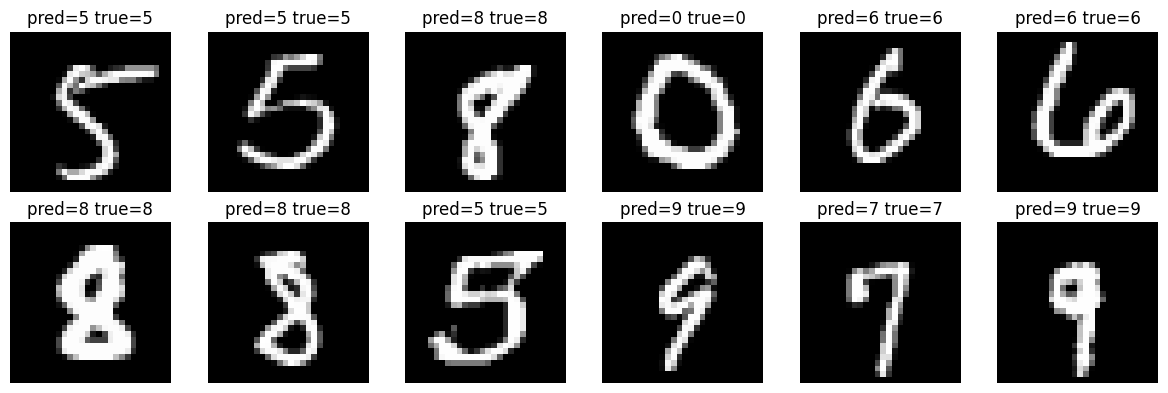

In [18]:
# To-Do: visualize a few predictions with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Ensure we have the model and x_test, y_test from Exercise 3
# To-Do: select N samples from x_test by using np.random.choice
N = 12
idx = np.random.choice(len(x_test), size=N, replace=False)
x_vis = x_test[idx]
y_true = y_test[idx]

# To-Do: get predictions
y_prob = model.predict(x_vis)
y_pred = np.argmax(y_prob, axis=1)

#plotting
cols = 6
rows = int(np.ceil(len(idx)/cols))
plt.figure(figsize=(12, 2*rows))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_test[k], cmap="gray")
    plt.title(f"pred={y_pred[i-1]} true={y_true[i-1]}" )
    plt.axis("off")
plt.tight_layout()
plt.show()
